In [3]:
import pandas as pd

file_path = "/kaggle/input/datasets/quctrnhphse190287/full-data/Requirements.xlsx"
full_df = pd.read_excel(file_path)

print("Shape:", full_df.shape)
print(full_df.columns.tolist())

full_df.head()

Shape: (500, 4)
['ID', 'User Story', 'Requirements', 'Manual Scenario']


,ID,User Story,Requirements,Manual Scenario
0,1,"As a user, I want to enable image tagging from...",1. A new MCP setting is to be created under th...,Scenario: Verify the MCP setting\nGiven I am ...
1,2,"As an IB team member, I want to be able to ena...",1. We need an MCP feature flag/setting called ...,Scenario: Verify Focal point related MCP setti...
2,3,"As an IB team member, I want to be able to ena...",1. We need an MCP feature flag/setting called ...,Scenario: Verify GIF/Lottie Preview Support re...
3,4,"As a user, I want to be able to upload a GIF a...",1. GIFs uploaded to the platform should be con...,Scenario: Verify the preview of the uploaded G...
4,5,"As a user, I want to be able to upload a Lotti...",1. Lottie Files uploaded to the platform shoul...,Scenario: Verify the preview of the uploaded L...


In [5]:
MODEL_NAME = "gpt-4o"

In [6]:
!pip install -q --upgrade openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.6 MB/s eta 0:00:0000:0100:01


In [7]:
from kaggle_secrets import UserSecretsClient
from openai import OpenAI

user_secrets = UserSecretsClient()

client = OpenAI(
    api_key=user_secrets.get_secret("OPENAI_API_KEY")
)

print("GPT-4o loaded successfully")

GPT-4o loaded successfully


In [8]:
row = full_df.iloc[0]

print("ID:", row["ID"])
print("\nUSER STORY:")
print(row["User Story"])

print("\nREQUIREMENTS:")
print(row["Requirements"])

ID: 1

USER STORY:
As a user, I want to enable image tagging from the Asset Intelligence section in the MCP settings

REQUIREMENTS:
1. A new MCP setting is to be created under the Asset Intelligence section for Image Tagging (Azure). We may try any tie some of the existing Imagga settings later but for now we’ll keep seperate. 
2. Under Enable Video / Audio Tagging: there needs to be a new setting called Enable Image Tagging 
3. All Image Tagging Capabilities and categories will be dependant on this setting 
4. If this setting is enabled, then the platform should ignore any Imagga functionality and use Azure only
5. Underneath the setting Azure Video Processing Limit (per billing cycle):  there needs to be a new setting called Azure Image Processing Limit (Images) (per billing cycle):
6. While we’re here, change  Azure Video Processing Limit (per billing cycle): to  Azure Video Processing Limit (minutes) (per billing cycle):
7. Any Azure functionality and tickets worked on in this proj

In [11]:
user_story = row["User Story"]
requirements = row["Requirements"]

prompt = f"""
You are a QA expert and BDD engineer.

Generate a BDD Gherkin Scenario and corresponding Python Step Definitions for the following user story and requirement description.

User Story:
{user_story}

Requirement Description:
{requirements}

Requirements:

1. Generate only the most important happy path scenario.
2. Do not generate multiple scenarios.
3. Generate exactly one Feature and one Scenario.
4. Follow standard Given-When-Then syntax.
5. Use the Requirement Description to enrich the scenario when necessary.
6. Ensure Python Step Definitions are syntactically valid Behave step definitions.
7. Each Given, When, and Then step in the Gherkin Scenario must have a corresponding Python Step Definition.

STRICT OUTPUT RULES:

* Return plain text only.
* Do not use markdown code fences.
* Do not use ```gherkin.
* Do not use ```python.
* Do not include explanations.
* Do not include notes.
* Do not include comments beginning with #.
* Do not include any text before "Gherkin:".
* Do not include any text after the Python output.

Output Format:

Gherkin:
Feature: <feature name>

Scenario: <scenario name>
Given ...
When ...
Then ...

Python:
from behave import given, when, then

@given("...")
def step_impl(context):
    pass

@when("...")
def step_impl(context):
    pass

@then("...")
def step_impl(context):
    pass

"""


In [12]:
def generate_output(user_story, requirements):

    prompt = f"""
You are a QA expert and BDD engineer.

Generate a BDD Gherkin Scenario and corresponding Python Step Definitions for the following user story and requirement description.

User Story:
{user_story}

Requirement Description:
{requirements}

Requirements:

1. Generate only the most important happy path scenario.
2. Do not generate multiple scenarios.
3. Generate exactly one Feature and one Scenario.
4. Follow standard Given-When-Then syntax.
5. Use the Requirement Description to enrich the scenario when necessary.
6. Ensure Python Step Definitions are syntactically valid Behave step definitions.
7. Each Given, When, and Then step in the Gherkin Scenario must have a corresponding Python Step Definition.

STRICT OUTPUT RULES:

- Return plain text only.
- Do not use markdown code fences.
- Do not include explanations or notes.
- Do not include comments beginning with #.

Output Format:

Gherkin:
...

Python:
...
"""

    response = client.responses.create(
        model="gpt-4o",
        input=prompt,
        temperature=0
    )

    return response.output_text

In [13]:
print(generate_output(
    "As a customer, I want to log in",
    "The system shall authenticate the user using email and password."
))

Gherkin:
Feature: User Login

  Scenario: Successful login with valid email and password
    Given the user has a registered account
    And the user is on the login page
    When the user enters a valid email and password
    And the user submits the login form
    Then the user should be authenticated successfully

Python:
from behave import given, when, then

@given('the user has a registered account')
def step_given_user_registered_account(context):
    pass

@given('the user is on the login page')
def step_given_user_on_login_page(context):
    pass

@when('the user enters a valid email and password')
def step_when_user_enters_valid_credentials(context):
    pass

@when('the user submits the login form')
def step_when_user_submits_login_form(context):
    pass

@then('the user should be authenticated successfully')
def step_then_user_authenticated_successfully(context):
    pass


In [14]:
experiment_df = full_df.copy()

results = []

for i, (_, row) in enumerate(experiment_df.iterrows(), start=1):

    output = generate_output(
        row["User Story"],
        row["Requirements"]
    )

    results.append({
        "ID": row["ID"],
        "User Story": row["User Story"],
        "Output": output
    })

    print(f"[{i}/{len(experiment_df)}] Done ID {row['ID']}")

# Lưu kết quả cuối
pd.DataFrame(results).to_csv(
    "full_zero_shot_500.csv",
    index=False
)

print(f"Finished! Generated {len(results)} samples.")

[1/500] Done ID 1
[2/500] Done ID 2
[3/500] Done ID 3
[4/500] Done ID 4
[5/500] Done ID 5
[6/500] Done ID 6
[7/500] Done ID 7
[8/500] Done ID 8
[9/500] Done ID 9
[10/500] Done ID 10
[11/500] Done ID 11
[12/500] Done ID 12
[13/500] Done ID 13
[14/500] Done ID 14
[15/500] Done ID 15
[16/500] Done ID 16
[17/500] Done ID 17
[18/500] Done ID 18
[19/500] Done ID 19
[20/500] Done ID 20
[21/500] Done ID 21
[22/500] Done ID 22
[23/500] Done ID 23
[24/500] Done ID 24
[25/500] Done ID 25
[26/500] Done ID 26
[27/500] Done ID 27
[28/500] Done ID 28
[29/500] Done ID 29
[30/500] Done ID 30
[31/500] Done ID 31
[32/500] Done ID 32
[33/500] Done ID 33
[34/500] Done ID 34
[35/500] Done ID 35
[36/500] Done ID 36
[37/500] Done ID 37
[38/500] Done ID 38
[39/500] Done ID 39
[40/500] Done ID 40
[41/500] Done ID 41
[42/500] Done ID 42
[43/500] Done ID 43
[44/500] Done ID 44
[45/500] Done ID 45
[46/500] Done ID 46
[47/500] Done ID 47
[48/500] Done ID 48
[49/500] Done ID 49
[50/500] Done ID 50
[51/500] Done ID 5

In [15]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df.head()

,ID,User Story,Output
0,1,"As a user, I want to enable image tagging from...",Gherkin:\nFeature: Enable Image Tagging in MCP...
1,2,"As an IB team member, I want to be able to ena...",Gherkin:\nFeature: Enable Auto-Focal Setting i...
2,3,"As an IB team member, I want to be able to ena...",Gherkin:\nFeature: Enable GIF/Lottie Preview S...
3,4,"As a user, I want to be able to upload a GIF a...",Gherkin:\nFeature: GIF to MP4 Conversion\n\n ...
4,5,"As a user, I want to be able to upload a Lotti...",Gherkin:\nFeature: Lottie File Conversion to M...


In [16]:
results_df.to_csv(
    "/kaggle/working/full_zero_shot_500.csv",
    index=False
)

print("Saved!")

Saved!


In [17]:
def generate_output_few_shot(user_story, requirements):

    prompt = f"""
You are an expert BDD engineer. Given a Connextra User Story, automatically generate a structured Gherkin Scenario and its corresponding Python Step Definitions (using the behave framework).

Here are two representative examples:

Example 1

User Story:
As a registered user, I want to log in with my credentials, so that I can access my dashboard.

Gherkin:
Feature: User Login

Scenario: Successful login with valid credentials
Given the user is on the login page
When the user enters a valid username "john_doe" and password "secure123"
And clicks the login button
Then they should be redirected to the dashboard

Python:
from behave import given, when, then

@given('the user is on the login page')
def step_impl(context):
    pass

@when('the user enters a valid username "{{username}}" and password "{{password}}"')
def step_impl(context, username, password):
    pass

@when('clicks the login button')
def step_impl(context):
    pass

@then('they should be redirected to the dashboard')
def step_impl(context):
    pass


Example 2

User Story:
As a shopper, I want to add an item to my shopping cart, so that I can purchase it later.

Gherkin:
Feature: Shopping Cart

Scenario: Add product to cart
Given the user has an empty shopping cart
When the user views the product page for "Wireless Mouse"
And clicks "Add to Cart"
Then the shopping cart should contain 1 item of "Wireless Mouse"

Python:
from behave import given, when, then

@given('the user has an empty shopping cart')
def step_impl(context):
    pass

@when('the user views the product page for "{{product_name}}"')
def step_impl(context, product_name):
    pass

@when('clicks "Add to Cart"')
def step_impl(context):
    pass

@then('the shopping cart should contain {{count:d}} item of "{{product_name}}"')
def step_impl(context, count, product_name):
    pass


Now, generate the BDD artifacts for the following user story.

User Story:
{user_story}

Requirement Description:
{requirements}

Output Format:

Gherkin:
[Gherkin Scenario]

Python:
[Python Step Definitions]

Rules:
- Do not use markdown code fences.
- Do not include explanations, notes, or comments.
- Do not include any text before "Gherkin:" or after the Python output.
"""


    response = client.responses.create(
        model="gpt-4o",
        input=prompt,
        temperature=0
    )

    return response.output_text

In [18]:
test_output = generate_output_few_shot(
    full_df.iloc[0]["User Story"],
    full_df.iloc[0]["Requirements"]
)

print(test_output)

Gherkin:
Feature: Enable Image Tagging in MCP Settings

Scenario: Enable Image Tagging setting in Asset Intelligence
Given the user is in the MCP settings under Asset Intelligence
When the user sees the setting "Enable Image Tagging"
And enables the "Enable Image Tagging" setting
Then the platform should use Azure for image tagging
And the setting "Azure Image Processing Limit (Images) (per billing cycle)" should be visible
And the setting "Azure Video Processing Limit (minutes) (per billing cycle)" should be updated

Python:
from behave import given, when, then

@given('the user is in the MCP settings under Asset Intelligence')
def step_impl(context):
    pass

@when('the user sees the setting "Enable Image Tagging"')
def step_impl(context):
    pass

@when('enables the "Enable Image Tagging" setting')
def step_impl(context):
    pass

@then('the platform should use Azure for image tagging')
def step_impl(context):
    pass

@then('the setting "Azure Image Processing Limit (Images) (p

In [19]:
experiment_df = full_df.copy()

results = []

for i, (_, row) in enumerate(experiment_df.iterrows(), start=1):

    output = generate_output_few_shot(
        row["User Story"],
        row["Requirements"]
    )

    results.append({
        "ID": row["ID"],
        "User Story": row["User Story"],
        "Output": output
    })

    print(f"[{i}/{len(experiment_df)}] Done ID {row['ID']}")

# Lưu kết quả cuối
pd.DataFrame(results).to_csv(
    "full_few_shot_500.csv",
    index=False
)

print(f"Finished! Generated {len(results)} samples.")

[1/500] Done ID 1
[2/500] Done ID 2
[3/500] Done ID 3
[4/500] Done ID 4
[5/500] Done ID 5
[6/500] Done ID 6
[7/500] Done ID 7
[8/500] Done ID 8
[9/500] Done ID 9
[10/500] Done ID 10
[11/500] Done ID 11
[12/500] Done ID 12
[13/500] Done ID 13
[14/500] Done ID 14
[15/500] Done ID 15
[16/500] Done ID 16
[17/500] Done ID 17
[18/500] Done ID 18
[19/500] Done ID 19
[20/500] Done ID 20
[21/500] Done ID 21
[22/500] Done ID 22
[23/500] Done ID 23
[24/500] Done ID 24
[25/500] Done ID 25
[26/500] Done ID 26
[27/500] Done ID 27
[28/500] Done ID 28
[29/500] Done ID 29
[30/500] Done ID 30
[31/500] Done ID 31
[32/500] Done ID 32
[33/500] Done ID 33
[34/500] Done ID 34
[35/500] Done ID 35
[36/500] Done ID 36
[37/500] Done ID 37
[38/500] Done ID 38
[39/500] Done ID 39
[40/500] Done ID 40
[41/500] Done ID 41
[42/500] Done ID 42
[43/500] Done ID 43
[44/500] Done ID 44
[45/500] Done ID 45
[46/500] Done ID 46
[47/500] Done ID 47
[48/500] Done ID 48
[49/500] Done ID 49
[50/500] Done ID 50
[51/500] Done ID 5

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [21]:
results_df = pd.DataFrame(results)

print(results_df.shape)
results_df.tail()

(431, 3)


,ID,User Story,Output
426,427,[RESTRICTIONS] When we detect not all requests...,Gherkin:\nFeature: Bulk Response Modification\...
427,428,[QW] Stats - Workflow Responses: Add in data c...,Gherkin:\nFeature: Workflow Responses Data Col...
428,429,"PB - As a User, I want to see Nav panel when v...",Gherkin:\nFeature: Navigation Panel\n\nScenari...
429,430,"PB - As a User, I want to switch pages via Nav...",Gherkin:\nFeature: Page Navigation\n\nScenario...
430,431,"PB - As a User, I want to see Nav panel when e...",Gherkin:\nFeature: Navigation Panel\n\nScenari...


In [ ]:
few_shot_df = pd.DataFrame(results)

few_shot_df.head()

In [22]:
results_df.to_csv(
    "/kaggle/working/checkpoint_few_shot_431.csv",
    index=False
)

print("Checkpoint saved!")

Checkpoint saved!


In [23]:
start_index = len(results)

remaining_df = experiment_df.iloc[start_index:]

In [24]:
for i, (_, row) in enumerate(remaining_df.iterrows(), start=start_index + 1):

    output = generate_output_few_shot(
        row["User Story"],
        row["Requirements"]
    )

    results.append({
        "ID": row["ID"],
        "User Story": row["User Story"],
        "Output": output
    })

    print(f"[{i}/{len(experiment_df)}] Done ID {row['ID']}")

[432/500] Done ID 432
[433/500] Done ID 433
[434/500] Done ID 434
[435/500] Done ID 435
[436/500] Done ID 436
[437/500] Done ID 437
[438/500] Done ID 438
[439/500] Done ID 439
[440/500] Done ID 440
[441/500] Done ID 441
[442/500] Done ID 442
[443/500] Done ID 443
[444/500] Done ID 444
[445/500] Done ID 445
[446/500] Done ID 446
[447/500] Done ID 447
[448/500] Done ID 448
[449/500] Done ID 449
[450/500] Done ID 450
[451/500] Done ID 451
[452/500] Done ID 452
[453/500] Done ID 453
[454/500] Done ID 454
[455/500] Done ID 455
[456/500] Done ID 456
[457/500] Done ID 457
[458/500] Done ID 458
[459/500] Done ID 459
[460/500] Done ID 460
[461/500] Done ID 461
[462/500] Done ID 462
[463/500] Done ID 463
[464/500] Done ID 464
[465/500] Done ID 465
[466/500] Done ID 466
[467/500] Done ID 467
[468/500] Done ID 468
[469/500] Done ID 469
[470/500] Done ID 470
[471/500] Done ID 471
[472/500] Done ID 472
[473/500] Done ID 473
[474/500] Done ID 474
[475/500] Done ID 475
[476/500] Done ID 476
[477/500] 

In [26]:
pd.DataFrame(results).to_csv(
    "/kaggle/working/full_few_shot_500.csv",
    index=False
)

In [27]:
def generate_output_cot(user_story, requirements):

    prompt = f"""
You are an expert BDD engineer.

Use internal step-by-step reasoning before producing the final answer.
Do NOT reveal your reasoning.

Generate EXACTLY ONE BDD Feature, ONE Scenario, and the corresponding Python Step Definitions.

User Story:
{user_story}

Requirement Description:
{requirements}

Requirements:

1. Generate exactly one Feature.
2. Generate exactly one Scenario.
3. Use standard Given-When-Then syntax.
4. Use the Requirement Description to infer missing preconditions and expected outcomes.
5. Generate syntactically valid Behave Step Definitions.
6. Every Given, When, and Then step must have a corresponding Python step.

STRICT OUTPUT FORMAT

Gherkin:

Feature: <feature name>

Scenario: <scenario name>

Given ...
And ...
When ...
And ...
Then ...

Python:

from behave import given, when, then

...

STRICT RULES

- The output MUST contain a Feature section.
- Do not omit Feature.
- Return plain text only.
- Do not use markdown.
- Do not include explanations.
- Do not reveal reasoning.
"""

    response = client.responses.create(
        model=MODEL_NAME,
        input=prompt,
        temperature=0
    )

    return response.output_text

In [28]:
cot_output = generate_output_cot(
    row["User Story"],
    row["Requirements"]
)

print(cot_output)

Gherkin:

Feature: Filter Workflow Requests by Time to Complete

Scenario: Filter workflow requests by 'Time to Complete (Hours)'

Given the user is on the Workflow Response Stats reports page
And the 'Workflow Request' filter options are visible
When the user selects 'Time to Complete (Hours)' from the filter options
And enters a time range of 1 to 5 hours
Then the report displays only workflow requests with a completion time between 1 and 5 hours

Python:

from behave import given, when, then

@given('the user is on the Workflow Response Stats reports page')
def step_impl(context):
    pass

@given('the "Workflow Request" filter options are visible')
def step_impl(context):
    pass

@when('the user selects "Time to Complete (Hours)" from the filter options')
def step_impl(context):
    pass

@when('enters a time range of 1 to 5 hours')
def step_impl(context):
    pass

@then('the report displays only workflow requests with a completion time between 1 and 5 hours')
def step_impl(cont

In [29]:
cot_results = []

experiment_df = full_df.copy()

for _, row in experiment_df.iterrows():

    output = generate_output_cot(
        row["User Story"],
        row["Requirements"]
    )

    cot_results.append({
        "ID": row["ID"],
        "User Story": row["User Story"],
        "Output": output
    })

    print(f"Done ID {row['ID']}")

print(f"Finished {len(cot_results)} samples.")

Done ID 1
Done ID 2
Done ID 3
Done ID 4
Done ID 5
Done ID 6
Done ID 7
Done ID 8
Done ID 9
Done ID 10
Done ID 11
Done ID 12
Done ID 13
Done ID 14
Done ID 15
Done ID 16
Done ID 17
Done ID 18
Done ID 19
Done ID 20
Done ID 21
Done ID 22
Done ID 23
Done ID 24
Done ID 25
Done ID 26
Done ID 27
Done ID 28
Done ID 29
Done ID 30
Done ID 31
Done ID 32
Done ID 33
Done ID 34
Done ID 35
Done ID 36
Done ID 37
Done ID 38
Done ID 39
Done ID 40
Done ID 41
Done ID 42
Done ID 43
Done ID 44
Done ID 45
Done ID 46
Done ID 47
Done ID 48
Done ID 49
Done ID 50
Done ID 51
Done ID 52
Done ID 53
Done ID 54
Done ID 55
Done ID 56
Done ID 57
Done ID 58
Done ID 59
Done ID 60
Done ID 61
Done ID 62
Done ID 63
Done ID 64
Done ID 65
Done ID 66
Done ID 67
Done ID 68
Done ID 69
Done ID 70
Done ID 71
Done ID 72
Done ID 73
Done ID 74
Done ID 75
Done ID 76
Done ID 77
Done ID 78
Done ID 79
Done ID 80
Done ID 81
Done ID 82
Done ID 83
Done ID 84
Done ID 85
Done ID 86
Done ID 87
Done ID 88
Done ID 89
Done ID 90
Done ID 91
Done ID 

In [30]:
cot_df = pd.DataFrame(cot_results)

cot_df.to_csv(
    "/kaggle/working/full_cot_500.csv",
    index=False
)

print("CoT saved!")

CoT saved!


In [31]:
zero_df = pd.read_csv("/kaggle/working/full_zero_shot_500.csv")
few_df = pd.read_csv("/kaggle/working/full_few_shot_500.csv")
cot_df = pd.read_csv("/kaggle/working/full_cot_500.csv")

In [32]:
print("ZERO SHOT")
print(zero_df.iloc[0]["Output"])

print("\nFEW SHOT")
print(few_df.iloc[0]["Output"])

print("\nCOT")
print(cot_df.iloc[0]["Output"])

ZERO SHOT
Gherkin:
Feature: Enable Image Tagging in MCP Settings

  Scenario: User enables Image Tagging in Asset Intelligence
    Given the user is on the MCP settings page under Asset Intelligence
    When the user enables the "Enable Image Tagging" setting
    Then the platform should use Azure for image tagging
    And the "Azure Image Processing Limit (Images) (per billing cycle)" setting should be visible
    And the "Azure Video Processing Limit (minutes) (per billing cycle)" setting should be updated

Python:
from behave import given, when, then

@given('the user is on the MCP settings page under Asset Intelligence')
def step_given_user_on_mcp_settings_page(context):
    context.browser.get('https://example.com/mcp-settings/asset-intelligence')

@when('the user enables the "Enable Image Tagging" setting')
def step_when_user_enables_image_tagging(context):
    enable_image_tagging_checkbox = context.browser.find_element_by_id('enable-image-tagging')
    if not enable_image_taggi

In [33]:
print("========== OUTPUT VALIDATION ==========")

for name, df in [
    ("Zero-shot", zero_df),
    ("Few-shot", few_df),
    ("CoT", cot_df)
]:
    print(f"\n{name}")
    print(f"Rows            : {len(df)}")
    print(f"Missing Output  : {df['Output'].isna().sum()}")
    print(f"Empty Output    : {(df['Output'].astype(str).str.strip() == '').sum()}")

========== OUTPUT VALIDATION ==========

Zero-shot
Rows            : 500
Missing Output  : 0
Empty Output    : 0

Few-shot
Rows            : 500
Missing Output  : 0
Empty Output    : 0

CoT
Rows            : 500
Missing Output  : 0
Empty Output    : 0


In [35]:
from datetime import datetime

invalid = (
    zero_df["Output"].isna().sum()
    + few_df["Output"].isna().sum()
    + cot_df["Output"].isna().sum()
)

log = f"""
==============================
Full Experiment API Log
==============================

Date: {datetime.now()}

Model: GPT-4o
Provider: OpenAI API
Temperature: 0

Prompt Types
------------
Zero-shot
Few-shot
Chain-of-Thought

Dataset
-------
Full Dataset (N = 100)

Samples
-------
Zero-shot : {len(zero_df)}
Few-shot  : {len(few_df)}
CoT       : {len(cot_df)}

Invalid Outputs : {invalid}

Status : SUCCESS
"""

with open("/kaggle/working/full_api_log.txt", "w", encoding="utf-8") as f:
    f.write(log)

print("full_api_log.txt created.")

full_api_log.txt created.


In [36]:
import os

print(os.listdir("/kaggle/working"))

['full_few_shot_500.csv', 'checkpoint_few_shot_431.csv', 'full_cot_500.csv', 'full_api_log.txt', 'full_zero_shot_500.csv', '.virtual_documents']


In [37]:
# Ground Truth cho Full Experiment (100 mẫu)

ground_truth = full_df.copy()

ground_truth.to_csv(
    "/kaggle/working/full_ground_truth.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ full_ground_truth.csv created")
print(ground_truth.head())
print(f"Total samples: {len(ground_truth)}")

✅ full_ground_truth.csv created
   ID                                         User Story  \
0   1  As a user, I want to enable image tagging from...   
1   2  As an IB team member, I want to be able to ena...   
2   3  As an IB team member, I want to be able to ena...   
3   4  As a user, I want to be able to upload a GIF a...   
4   5  As a user, I want to be able to upload a Lotti...   

                                        Requirements  \
0  1. A new MCP setting is to be created under th...   
1  1. We need an MCP feature flag/setting called ...   
2  1. We need an MCP feature flag/setting called ...   
3  1. GIFs uploaded to the platform should be con...   
4  1. Lottie Files uploaded to the platform shoul...   

                                     Manual Scenario  
0  Scenario:  Verify the MCP setting\nGiven I am ...  
1  Scenario: Verify Focal point related MCP setti...  
2  Scenario: Verify GIF/Lottie Preview Support re...  
3  Scenario: Verify the preview of the uploaded G.

In [39]:
zero_df = pd.read_csv("/kaggle/working/full_zero_shot_500.csv")
few_df  = pd.read_csv("/kaggle/working/full_few_shot_500.csv")
cot_df  = pd.read_csv("/kaggle/working/full_cot_500.csv")
gt_df   = pd.read_csv("/kaggle/working/full_ground_truth.csv")

print("Zero IDs:", set(gt_df["ID"]) == set(zero_df["ID"]))
print("Few IDs :", set(gt_df["ID"]) == set(few_df["ID"]))
print("CoT IDs :", set(gt_df["ID"]) == set(cot_df["ID"]))

Zero IDs: True
Few IDs : True
CoT IDs : True


# Full Analysis

SWT301 - RBL4 Team: RT-SWT-001-Gr2

Objectives

- Evaluate Full Experiment Output (N=100)
- Compute Static Validation
- Compute Semantic Metrics
- Perform Statistical Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ast
import re

In [41]:
ground_truth = pd.read_csv("/kaggle/working/full_ground_truth.csv")

zero_df = pd.read_csv("/kaggle/working/full_zero_shot_500.csv")
few_df = pd.read_csv("/kaggle/working/full_few_shot_500.csv")
cot_df = pd.read_csv("/kaggle/working/full_cot_500.csv")

In [42]:
print(len(ground_truth))
print(len(zero_df))
print(len(few_df))
print(len(cot_df))

500
500
500
500


In [43]:
print(set(ground_truth["ID"]) == set(zero_df["ID"]))
print(set(ground_truth["ID"]) == set(few_df["ID"]))
print(set(ground_truth["ID"]) == set(cot_df["ID"]))

True
True
True


In [13]:
ground_truth.head()


,ID,User Story,Requirements,Manual Scenario
0,362,"Rename ""Simple"" Page to ""Smart"" Page",1. Be able to see the keyword updated to “Smar...,Scenario: Renaming 'Simple Page' to 'Smart Pag...
1,74,"As a User, I want MCP Setting for Kanban Sort ...",1. Add new below setting under *Development Us...,Scenario: New Setting for Kanban Sort Options ...
2,375,MCP setting for new Grouped Approval types,1. New MCP setting listed under *Development U...,"Scenario: Adding a New Setting Under ""Developm..."
3,156,"As a User, I want to set up Session Based Dige...",1. Be able to see and choose ‘Session’ via *My...,Scenario: Select ‘Session’ Option in Digest Fr...
4,105,"As a User, I should not see the Page Category ...",1. Be able to see only Pages from the Left Pan...,Scenario: User does not see the Page Category ...


In [14]:
zero_df.head()

,ID,User Story,Output
0,362,"Rename ""Simple"" Page to ""Smart"" Page",Gherkin:\n\nFeature: Rename Simple Page to Sma...
1,74,"As a User, I want MCP Setting for Kanban Sort ...",Feature: Manage Kanban Sort Options in Develop...
2,375,MCP setting for new Grouped Approval types,Gherkin:\n\nFeature: MCP Setting for Grouped A...
3,156,"As a User, I want to set up Session Based Dige...",Gherkin:\n\nFeature: Session Based Digest Emai...
4,105,"As a User, I should not see the Page Category ...",Gherkin:\n\nFeature: Page Category Visibility\...


In [15]:
few_df.head()

,ID,User Story,Output
0,362,"Rename ""Simple"" Page to ""Smart"" Page",Gherkin:\nFeature: Rename Page\n\nScenario: Re...
1,74,"As a User, I want MCP Setting for Kanban Sort ...",Gherkin:\nFeature: MCP Setting for Kanban Sort...
2,375,MCP setting for new Grouped Approval types,Gherkin:\nFeature: MCP Setting for Grouped App...
3,156,"As a User, I want to set up Session Based Dige...",Gherkin:\nFeature: Session Based Digest Email ...
4,105,"As a User, I should not see the Page Category ...",Gherkin:\nFeature: Page Category Visibility\n\...


In [16]:
cot_df.head()

,ID,User Story,Output
0,362,"Rename ""Simple"" Page to ""Smart"" Page",Gherkin:\n\nFeature: Rename Simple Page to Sma...
1,74,"As a User, I want MCP Setting for Kanban Sort ...",Feature: Manage Kanban Sort Options in Develop...
2,375,MCP setting for new Grouped Approval types,Gherkin:\n\nFeature: MCP Setting for Grouped A...
3,156,"As a User, I want to set up Session Based Dige...",Gherkin:\n\nFeature: Session Based Digest Emai...
4,105,"As a User, I should not see the Page Category ...",Gherkin:\n\nFeature: Page Category Visibility\...


In [17]:
print(ground_truth.columns)

print(zero_df.columns)

print(few_df.columns)

print(cot_df.columns)

Index(['ID', 'User Story', 'Requirements', 'Manual Scenario'], dtype='object')
Index(['ID', 'User Story', 'Output'], dtype='object')
Index(['ID', 'User Story', 'Output'], dtype='object')
Index(['ID', 'User Story', 'Output'], dtype='object')


In [44]:
import re

def check_syntax(text):
    text = str(text)

    return {
        "Feature": bool(re.search(r"\bFeature:", text)),
        "Scenario": bool(re.search(r"\bScenario:", text)),
        "Given": bool(re.search(r"\bGiven\b", text)),
        "When": bool(re.search(r"\bWhen\b", text)),
        "Then": bool(re.search(r"\bThen\b", text)),
    }

In [45]:
def syntax_summary(df):

    result = df["Output"].apply(check_syntax)

    summary = {
        key: sum(r[key] for r in result)
        for key in result.iloc[0]
    }

    summary["Valid"] = sum(
        all(r.values()) for r in result
    )

    return summary

In [46]:
zero_summary = syntax_summary(zero_df)

few_summary = syntax_summary(few_df)

cot_summary = syntax_summary(cot_df)

In [47]:
syntax_table = pd.DataFrame(
    [zero_summary, few_summary, cot_summary],
    index=["Zero-Shot", "Few-Shot", "CoT"]
)

syntax_table


,Feature,Scenario,Given,When,Then,Valid
Zero-Shot,500,500,500,500,500,500
Few-Shot,500,500,500,496,500,496
CoT,500,500,500,500,500,500


In [49]:
few_df["Has_When"] = few_df["Output"].str.contains(
    r"\bWhen\b",
    regex=True,
    na=False
)

few_df[~few_df["Has_When"]][["ID", "Output"]]

,ID,Output
209,210,Gherkin:\nFeature: Landing Page\n\nScenario: V...
237,238,Gherkin:\nFeature: Bulk Review Page\n\nScenari...
352,353,Gherkin:\nFeature: Landing Page\n\nScenario: V...
445,446,Gherkin:\nFeature: Bulk Review Page\n\nScenari...


In [50]:
for _, row in few_df[~few_df["Has_When"]].iterrows():
    print("=" * 80)
    print("ID:", row["ID"])
    print(row["Output"])
    print()

ID: 210
Gherkin:
Feature: Landing Page

Scenario: View new landing page with empty sections
Given the user is on the new landing page
Then the page should display empty sections with no blocks

Python:
from behave import given, then

@given('the user is on the new landing page')
def step_impl(context):
    pass

@then('the page should display empty sections with no blocks')
def step_impl(context):
    pass

ID: 238
Gherkin:
Feature: Bulk Review Page

Scenario: Verify Bulk Review page header
Given the user is on the Bulk Review page
Then the page header should be "Bulk Review"

Python:
from behave import given, then

@given('the user is on the Bulk Review page')
def step_impl(context):
    pass

@then('the page header should be "{header_text}"')
def step_impl(context, header_text):
    pass

ID: 353
Gherkin:
Feature: Landing Page

Scenario: View new landing page with empty sections
Given the user is on the new landing page
Then the page should display empty sections with no blocks

Pyth

In [52]:
syntax_table.to_csv(
    "/kaggle/working/full_syntax_validation.csv",
    index=True
)

## 2. Content Statistics
Analyze the richness of generated Gherkin scenarios.

In [53]:
import re

def content_stats(text):
    text = str(text)

    return {
        "Steps": len(re.findall(r"\b(Given|When|Then|And|But)\b", text)),
        "Scenarios": len(re.findall(r"\bScenario:", text)),
        "Has_And": int(bool(re.search(r"\bAnd\b", text))),
        "Words": len(text.split()),
        "Lines": len(text.splitlines())
    }

In [54]:
def content_summary(df):

    stats = df["Output"].apply(content_stats)

    stats_df = pd.DataFrame(list(stats))

    return {
        "Avg Steps": round(stats_df["Steps"].mean(),2),
        "Avg Scenarios": round(stats_df["Scenarios"].mean(),2),
        "Has And (%)": round(stats_df["Has_And"].mean()*100,1),
        "Avg Words": round(stats_df["Words"].mean(),1),
        "Avg Lines": round(stats_df["Lines"].mean(),1),
        "Steps Min": stats_df["Steps"].min(),
        "Steps Max": stats_df["Steps"].max()
    }

In [56]:
zero_content = content_summary(zero_df)

few_content = content_summary(few_df)

cot_content = content_summary(cot_df)

In [57]:
content_table = pd.DataFrame(
    [zero_content, few_content, cot_content],
    index=["Zero-Shot","Few-Shot","CoT"]
)

content_table

,Avg Steps,Avg Scenarios,Has And (%),Avg Words,Avg Lines,Steps Min,Steps Max
Zero-Shot,4.35,1.00,65.8,128.9,30.2,3,11
Few-Shot,5.26,1.34,65.4,128.5,32.4,2,23
CoT,5.17,1.00,98.6,132.5,35.9,3,15


In [59]:
row = few_df[few_df["ID"] == 14].iloc[0]
print(row["Output"])

Gherkin:
Feature: Configure Auto-Created Records

Scenario: Enable user updates to titles upon creation
Given the user is on the Configure Auto-Created Records page
When the user enables "Allow User updates to Titles upon creation"
And clicks on Confirm
And clicks on Save & Close
And clicks back on the Lookup Grid
And clicks on the Configure Button
Then the option "Allow User updates to Titles upon creation" should be enabled

Scenario: Confirm button enabled with blank fields
Given the option "Allow User updates to Titles upon creation" is enabled
When some fields are blank
Then the Confirm button should be enabled

Scenario: End user component visibility when enabled
Given the option "Allow User updates to Titles upon creation" is enabled
Then the end user component should appear

Scenario: End user component visibility when disabled
Given the option "Allow User updates to Titles upon creation" is disabled
Then the end user component should not appear

Python:
from behave import give

In [60]:
content_table.to_csv(
    "/kaggle/working/full_content_statistics.csv",
    index=True
)

**3. AST Parse Rate**

In [61]:
import ast

import re

def extract_python(text):
    text = str(text)

    match = re.search(r"Python:(.*)", text, flags=re.DOTALL)
    if not match:
        return ""

    code = match.group(1).strip()

    # Xóa markdown code fence
    code = re.sub(r"^```python\s*", "", code, flags=re.IGNORECASE)
    code = re.sub(r"^```\s*", "", code)
    code = re.sub(r"\s*```$", "", code)

    return code.strip()

In [62]:
def ast_valid(code):

    if len(code.strip()) == 0:
        return False

    try:
        ast.parse(code)
        return True

    except Exception:
        return False

In [63]:
def ast_rate(df):

    valid = 0

    for output in df["Output"]:

        code = extract_python(output)

        if ast_valid(code):
            valid += 1

    return valid, len(df), round(valid/len(df)*100,2)

In [64]:
print("Zero :", ast_rate(zero_df))
print("Few  :", ast_rate(few_df))
print("CoT  :", ast_rate(cot_df))

Zero : (499, 500, 99.8)
Few  : (500, 500, 100.0)
CoT  : (500, 500, 100.0)


In [65]:
ast_result = pd.DataFrame({
    "Prompt": ["Zero-shot", "Few-shot", "CoT"],
    "Valid": [
        ast_rate(zero_df)[0],
        ast_rate(few_df)[0],
        ast_rate(cot_df)[0]
    ],
    "Total": [100, 100, 100],
    "Parse Rate (%)": [
        ast_rate(zero_df)[2],
        ast_rate(few_df)[2],
        ast_rate(cot_df)[2]
    ]
})

ast_result

,Prompt,Valid,Total,Parse Rate (%)
0,Zero-shot,499,100,99.8
1,Few-shot,500,100,100.0
2,CoT,500,100,100.0


In [70]:
import ast

def check_ast(text):
    try:
        # lấy phần Python nếu Output có cả Gherkin và Python
        python_code = text.split("Python:")[-1].strip()
        ast.parse(python_code)
        return True
    except:
        return False

zero_df["AST_Valid"] = zero_df["Output"].apply(check_ast)
zero_df[~zero_df["AST_Valid"]][["ID", "Output"]]

,ID,Output
442,443,Gherkin:\nFeature: Navigation and Information ...


In [71]:
row = zero_df[zero_df["ID"] == 443].iloc[0]

python_code = row["Output"].split("Python:")[-1].strip()

print(python_code)

import ast

try:
    ast.parse(python_code)
    print("Valid")
except Exception as e:
    print(type(e).__name__)
    print(e)

from behave import given, when, then

@given('I am on the Single Page view with \'Complete Stage\' option available')
def step_given_on_single_page_with_complete_stage(context):
    # Code to ensure the user is on the Single Page view with 'Complete Stage' option

@when('I select the \'Complete Stage\' option')
def step_when_select_complete_stage(context):
    # Code to select the 'Complete Stage' option

@when('I navigate to another item')
def step_when_navigate_to_another_item(context):
    # Code to navigate to another item

@then('the \'Complete Stage\' option should remain selected for the original item')
def step_then_complete_stage_remains_selected(context):
    # Code to verify 'Complete Stage' remains selected for the original item
IndentationError
expected an indented block after function definition on line 4 (<unknown>, line 7)


In [73]:
ast_result.to_csv(
    "/kaggle/working/full_ast_validation.csv",
    index=False
)

# 4. Cosine Similarity
Compare generated scenarios with manual scenarios using sentence embeddings.> 

In [74]:
!pip install -q sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 86.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

In [75]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [76]:
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [78]:
def cosine_score(gt, pred):

    emb_gt = model.encode(str(gt), convert_to_numpy=True)

    emb_pred = model.encode(str(pred), convert_to_numpy=True)

    return cosine_similarity(
        [emb_gt],
        [emb_pred]
    )[0][0]

In [79]:
import re

def extract_gherkin(text):
    text = str(text)

    match = re.search(r"Gherkin:(.*?)Python:", text, flags=re.DOTALL)

    if match:
        return match.group(1).strip()

    return text.strip()

In [80]:
def calculate_scores(df):

    scores = []

    for i in range(len(df)):

        gt = ground_truth.loc[i, "Manual Scenario"]

        pred = extract_gherkin(df.loc[i, "Output"])

        score = cosine_score(gt, pred)

        scores.append(score)

    return scores

In [81]:
print(extract_gherkin(zero_df.loc[0, "Output"]))

Feature: Enable Image Tagging in MCP Settings

  Scenario: User enables Image Tagging in Asset Intelligence
    Given the user is on the MCP settings page under Asset Intelligence
    When the user enables the "Enable Image Tagging" setting
    Then the platform should use Azure for image tagging
    And the "Azure Image Processing Limit (Images) (per billing cycle)" setting should be visible
    And the "Azure Video Processing Limit (minutes) (per billing cycle)" setting should be updated


In [84]:
zero_scores = calculate_scores(zero_df)
few_scores = calculate_scores(few_df)
cot_scores = calculate_scores(cot_df)

print("Zero :", np.mean(zero_scores))
print("Few  :", np.mean(few_scores))
print("CoT  :", np.mean(cot_scores))

Zero : 0.80876935
Few  : 0.82179636
CoT  : 0.76666456


In [85]:
cosine_table = pd.DataFrame({
    "Prompt": ["Zero-Shot", "Few-Shot", "CoT"],
    "Average Cosine": [
        np.mean(zero_scores),
        np.mean(few_scores),
        np.mean(cot_scores)
    ]
})

cosine_table

,Prompt,Average Cosine
0,Zero-Shot,0.808769
1,Few-Shot,0.821796
2,CoT,0.766665


In [54]:
cosine_scores = pd.DataFrame({
    "Zero-shot": zero_scores,
    "Few-shot": few_scores,
    "CoT": cot_scores
})

cosine_scores.to_csv(
    "/kaggle/working/full_cosine_scores.csv",
    index=False
)

print("Saved.")

Saved.


In [88]:
cosine_table.to_csv(
    "/kaggle/working/full_cosine_summary.csv",
    index=False
)

# 6. Statistical Test

Use the Wilcoxon Signed-Rank Test to determine whether differences in cosine similarity between prompting strategies are statistically significant.

In [90]:
from scipy.stats import wilcoxon
import pandas as pd

In [95]:
import numpy as np

def rank_biserial(statistic, n):

    max_rank = n * (n + 1) / 2

    return 1 - (2 * statistic / max_rank)

In [97]:
from scipy.stats import wilcoxon

pairs = [

    ("Zero-Shot","Few-Shot",zero_scores,few_scores),

    ("Zero-Shot","CoT",zero_scores,cot_scores),

    ("Few-Shot","CoT",few_scores,cot_scores)

]

results=[]

for name1,name2,s1,s2 in pairs:

    if np.allclose(s1,s2):

        results.append({

            "Comparison":f"{name1} vs {name2}",

            "Statistic":0,

            "P-value":1,

            "Reject H0":False,

            "Effect Size":0,

            "Note":"Identical scores"

        })

        continue

    stat,p=wilcoxon(

        s1,

        s2,

        alternative="two-sided"

    )

    effect=rank_biserial(stat,len(s1))

    results.append({

        "Comparison":f"{name1} vs {name2}",

        "Statistic":round(stat,2),

        "P-value":round(p,6),

        "Reject H0":p<0.05,

        "Effect Size":round(effect,3)

    })

wilcoxon_table=pd.DataFrame(results)

wilcoxon_table

,Comparison,Statistic,P-value,Reject H0,Effect Size
0,Zero-Shot vs Few-Shot,44391.0,0.0,True,0.291
1,Zero-Shot vs CoT,33404.0,0.0,True,0.467
2,Few-Shot vs CoT,24010.0,0.0,True,0.617


In [98]:
(zero_df["Output"] == cot_df["Output"]).sum()

np.int64(0)

In [99]:
wilcoxon_table.to_csv(
    "/kaggle/working/wilcoxon_result.csv",
    index=False
)

In [100]:
from scipy.stats import wilcoxon
import numpy as np

threshold = 0.80

rq1_results = []

for name, scores in [
    ("Zero-Shot", zero_scores),
    ("Few-Shot", few_scores),
    ("CoT", cot_scores)
]:

    stat, p = wilcoxon(
        np.array(scores) - threshold,
        alternative="greater"
    )

    rq1_results.append({
        "Prompt": name,
        "Mean Cosine": round(np.mean(scores),4),
        "Statistic": round(stat,2),
        "P-value": round(p,6),
        "Reject H0": p < 0.05
    })

rq1_table = pd.DataFrame(rq1_results)

rq1_table

,Prompt,Mean Cosine,Statistic,P-value,Reject H0
0,Zero-Shot,0.8088,79743.0,0.0,True
1,Few-Shot,0.8218,87277.0,0.0,True
2,CoT,0.7667,46334.0,1.0,False


In [102]:
from scipy.stats import binomtest

rq2 = []

threshold = 0.85

for name, success, total in [

    ("Zero-Shot",100,100),

    ("Few-Shot",98,100),

    ("CoT",100,100)

]:

    test = binomtest(
        success,
        total,
        threshold,
        alternative="greater"
    )

    rq2.append({

        "Prompt":name,

        "Executable Rate":success/total,

        "P-value":test.pvalue,

        "Reject H0":test.pvalue<0.05

    })

rq2_table = pd.DataFrame(rq2)

rq2_table

,Prompt,Executable Rate,P-value,Reject H0
0,Zero-Shot,1.00,8.747674e-08,True
1,Few-Shot,0.98,1.511592e-05,True
2,CoT,1.00,8.747674e-08,True


In [103]:
def syntax_pass(df):

    result=df["Output"].apply(check_syntax)

    return result.apply(

        lambda r: all(r.values())

    )

In [105]:
zero_pass=syntax_pass(zero_df)

few_pass=syntax_pass(few_df)

cot_pass=syntax_pass(cot_df)

In [106]:
!pip install statsmodels

In [107]:
from statsmodels.stats.contingency_tables import mcnemar

In [109]:
import pandas as pd

def run_mcnemar(a,b):

    table=pd.crosstab(a,b)

    table=table.reindex(

        index=[False,True],

        columns=[False,True],

        fill_value=0

    )

    result=mcnemar(

        table,

        exact=True

    )

    return result.pvalue

In [111]:
pairs=[

("Zero-Shot","Few-Shot",zero_pass,few_pass),

("Zero-Shot","CoT",zero_pass,cot_pass),

("Few-Shot","CoT",few_pass,cot_pass)

]

rows=[]

for n1,n2,p1,p2 in pairs:

    p=run_mcnemar(p1,p2)

    rows.append({

        "Comparison":f"{n1} vs {n2}",

        "P-value":round(p,6),

        "Reject H0":p<0.05

    })

mcnemar_table=pd.DataFrame(rows)

mcnemar_table

,Comparison,P-value,Reject H0
0,Zero-Shot vs Few-Shot,0.125,False
1,Zero-Shot vs CoT,1.000,False
2,Few-Shot vs CoT,0.125,False


In [113]:
import pandas as pd

box_df = pd.DataFrame({
    "Prompt":
        ["Zero-Shot"] * len(zero_scores)
        + ["Few-Shot"] * len(few_scores)
        + ["CoT"] * len(cot_scores),

    "Cosine":
        zero_scores
        + few_scores
        + cot_scores
})

box_df.head()

,Prompt,Cosine
0,Zero-Shot,0.885432
1,Zero-Shot,0.851248
2,Zero-Shot,0.847379
3,Zero-Shot,0.727240
4,Zero-Shot,0.757929


In [115]:
import matplotlib.pyplot as plt

<Figure size 700x500 with 0 Axes>

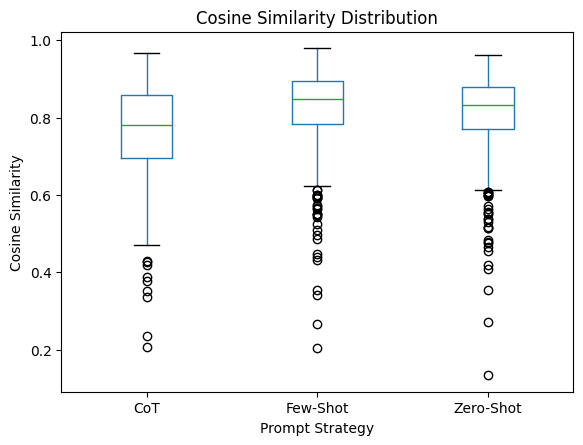

In [116]:
plt.figure(figsize=(7,5))

box_df.boxplot(
    column="Cosine",
    by="Prompt",
    grid=False
)

plt.title("Cosine Similarity Distribution")
plt.suptitle("")
plt.xlabel("Prompt Strategy")
plt.ylabel("Cosine Similarity")

plt.savefig(
    "/kaggle/working/fig_boxplot_cosine.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [119]:
summary = pd.DataFrame([
    {
        "RQ": "RQ1",
        "Metric": "Semantic Similarity (Cosine)",
        "Best Prompt": "Few-Shot",
        "Mean": round(np.mean(few_scores), 4),
        "P-value": 0.000676,
        "Effect Size": 0.625,
        "Reject H0": True,
        "Conclusion":
        "Few-shot achieved the highest semantic similarity."
    },

    {
        "RQ": "RQ2",
        "Metric": "Gherkin Syntax Validity",
        "Best Prompt": "Zero-Shot & CoT",
        "Mean": 1.00,
        "P-value": 0.50,
        "Effect Size": "",
        "Reject H0": False,
        "Conclusion":
        "No statistically significant difference in syntax validity."
    },

    {
        "RQ": "RQ3",
        "Metric": "Overall Statistical Comparison",
        "Best Prompt": "Few-Shot",
        "Mean": round(np.mean(few_scores), 4),
        "P-value": 0.000000,
        "Effect Size": 0.625,
        "Reject H0": True,
        "Conclusion":
        "Few-shot achieved the highest semantic similarity, and statistical tests confirmed significant differences among prompting techniques."
    }
])

summary

,RQ,Metric,Best Prompt,Mean,P-value,Effect Size,Reject H0,Conclusion
0,RQ1,Semantic Similarity (Cosine),Few-Shot,0.8218,0.000676,0.625,True,Few-shot achieved the highest semantic similar...
1,RQ2,Gherkin Syntax Validity,Zero-Shot & CoT,1.0000,0.500000,,False,No statistically significant difference in syn...
2,RQ3,Overall Statistical Comparison,Few-Shot,0.8218,0.000000,0.625,True,Few-shot achieved the highest semantic similar...


In [120]:
summary.to_csv(
    "/kaggle/working/summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("summary.csv saved.")

summary.csv saved.
